# **Boston Housing Price Analysis**

In [1]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/the-boston-houseprice-data")
print("Path to dataset files:", path)

100%|██████████| 12.3k/12.3k [00:00<00:00, 1.21MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/the-boston-houseprice-data/versions/1


In [2]:
import pandas as pd
df = pd.read_csv(path + '/boston.csv')
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


## Part 1 Exploratory Data Analysis (EDA)

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set(style="whitegrid")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None

Summary Statistics:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   

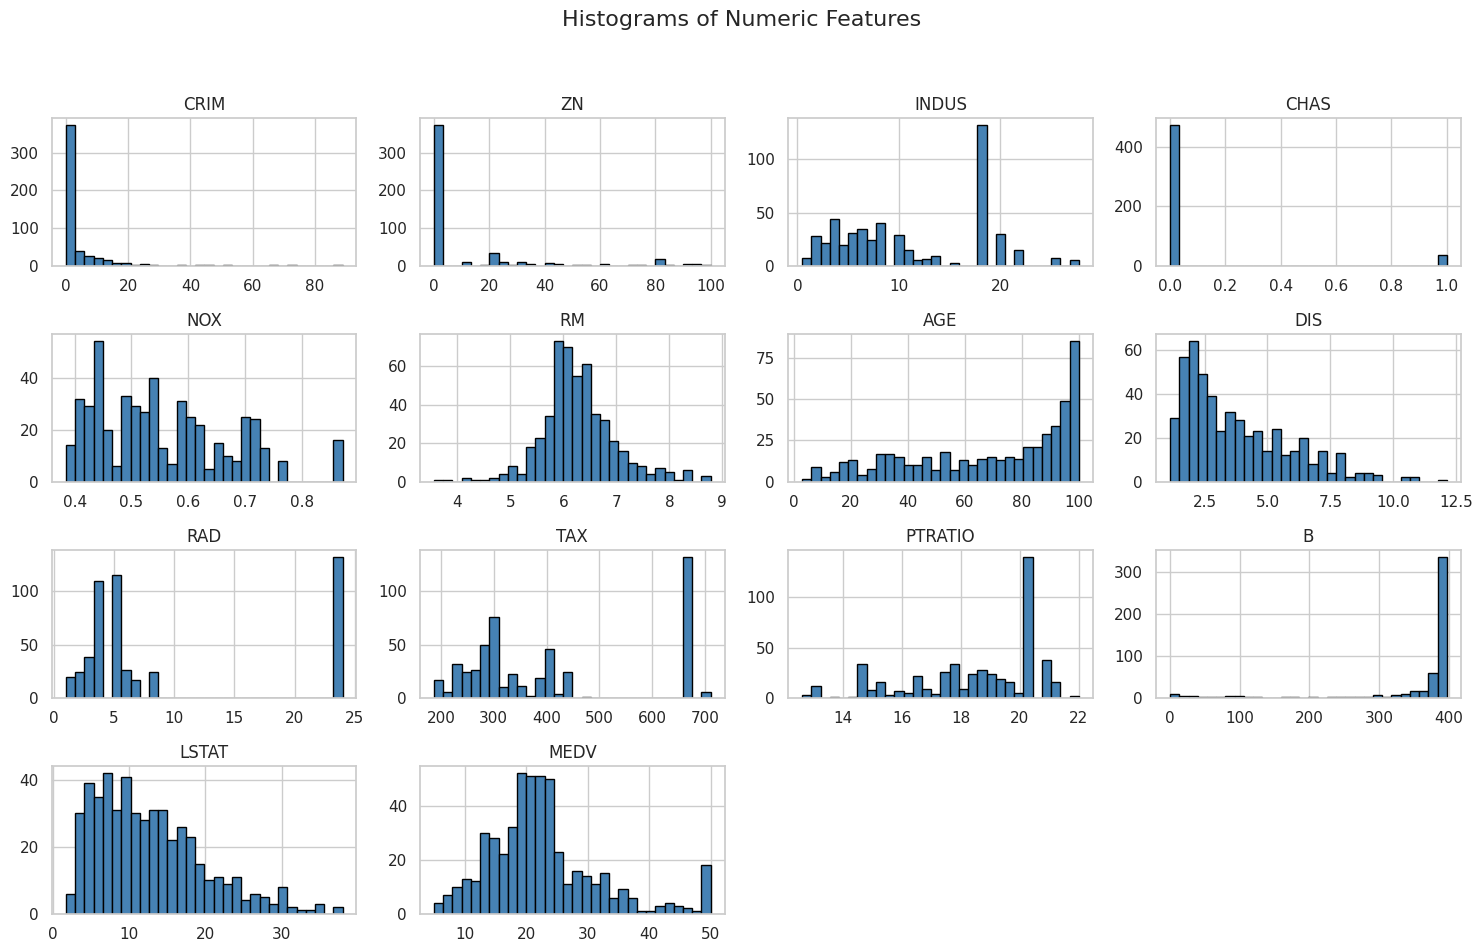

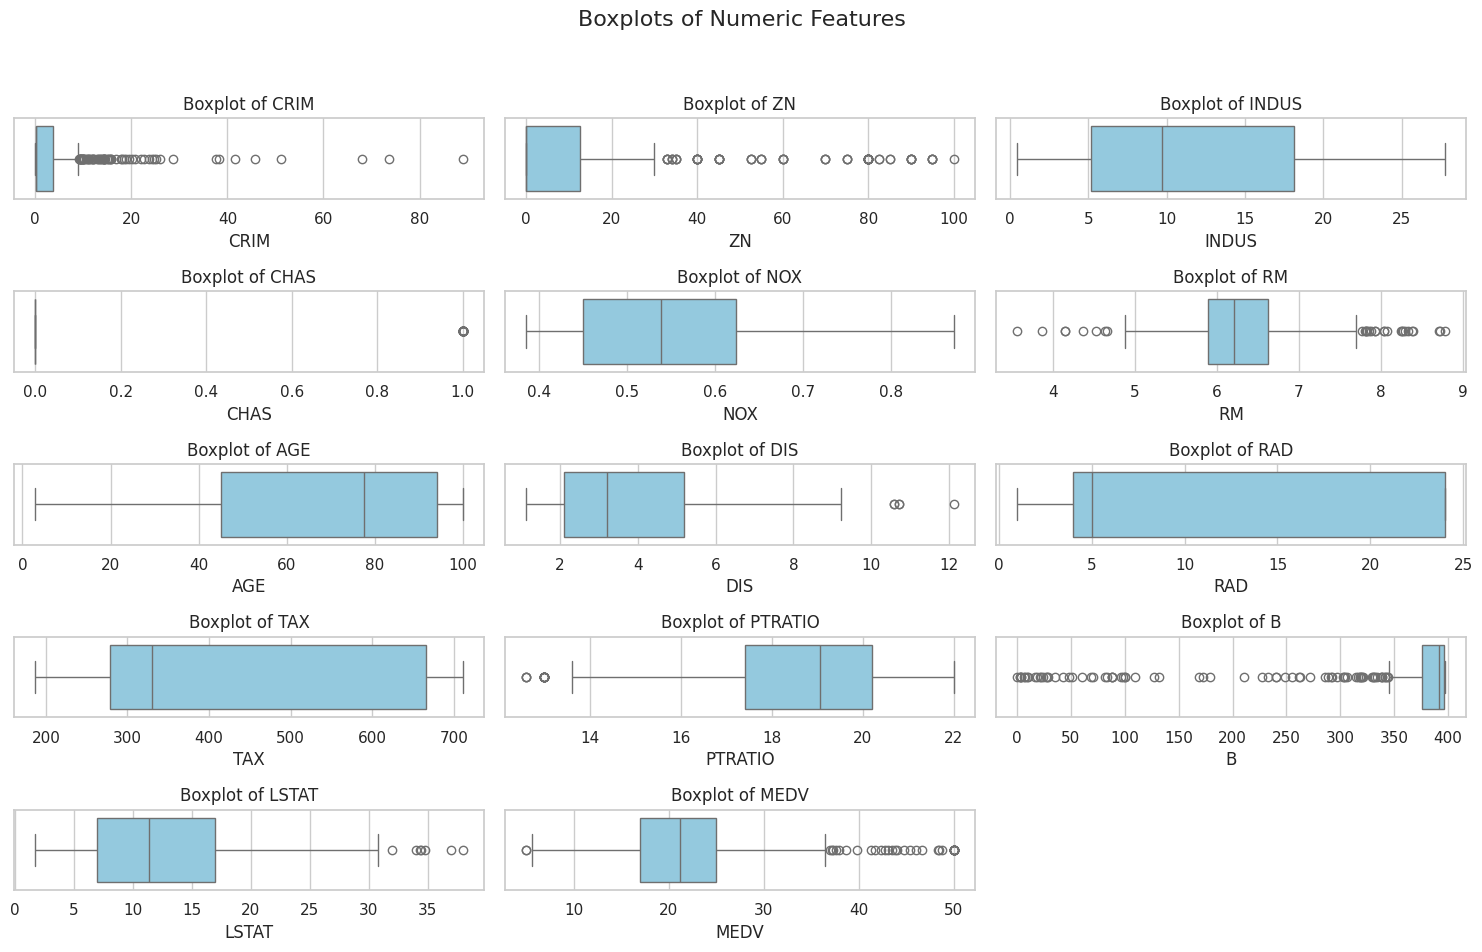

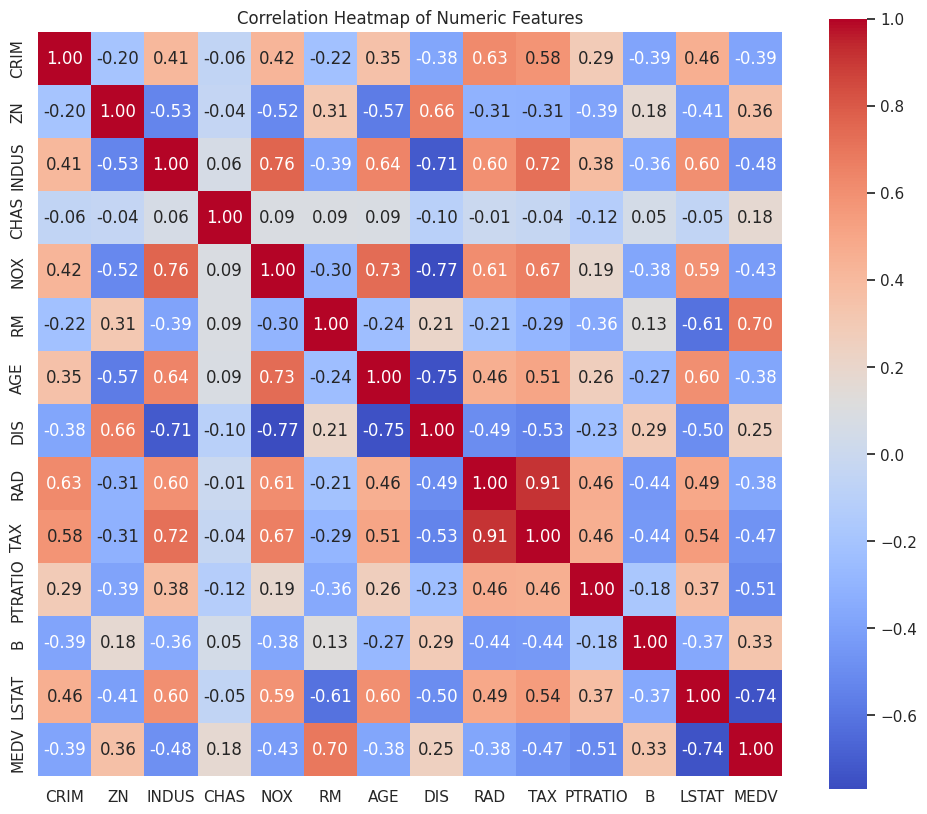

In [5]:
# Check data types, non-null counts
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check missing values
print("\nMissing Values in Each Column:")
missing_values = df.isnull().sum()
print(missing_values)

# Plot distributions by using histograms
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Box plots to identify outliers
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots of Numeric Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Correlation heatmap to identify relationships between variables
plt.figure(figsize=(12, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Part 2 Feature Engineering

### 1. Feature Selection

A Random Forest Regressor is used to compute feature importances for the Boston housing dataset. In this approach, the feature importances are used as the metric to validate the selection.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

Feature Importances:
    Feature  Importance
5        RM    0.503845
12    LSTAT    0.309509
7       DIS    0.060549
0      CRIM    0.038062
10  PTRATIO    0.016313
9       TAX    0.015661
4       NOX    0.015544
6       AGE    0.013840
11        B    0.012154
2     INDUS    0.007953
8       RAD    0.003811
1        ZN    0.001756
3      CHAS    0.001004


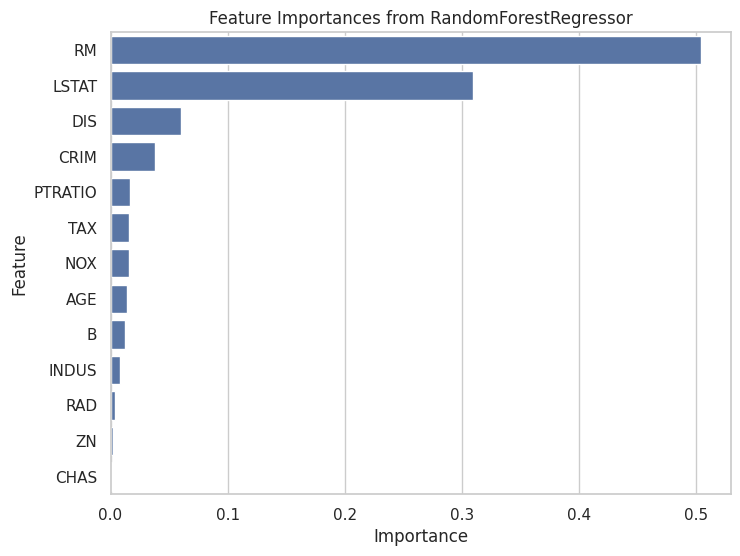

In [7]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use a RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Assess feature importances from the RandomForest model
importances = rf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)
print("Feature Importances:")
print(feat_imp_df)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title('Feature Importances from RandomForestRegressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

This random forest regressor metric shows how much each feature contributes to reducing the model prediction error. Higher importance values indicate stronger predictive power.

Key determinants: Features like RM (average number of rooms) and LSTAT (% lower status of the population) tend to emerge as the most influential predictors in this dataset.

*   RM is often associated with a positive influence on housing prices since apparently, more rooms usually indicate larger, more valuable homes.;
*   LSTAT usually has a negative influence on housing prices, meaning that a higher percentage of lower status residents tends to correlate with lower home values.

The model might also indicate other important features such as PTRATIO, NOX, or TAX, which could be considered in further analyses.

### 2. Feature Extraction

PCA is applied for dimensionality reduction and then compares the performance of a simple Linear Regression model trained on the original features versus the PCA-transformed features.

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA and choose number of components to explain 95% of variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train.shape[1])
print("Reduced number of features after PCA:", X_train_pca.shape[1])

# Use a Linear Regression model on the original features and a model on the the PCA-transformed features
lr_original = LinearRegression()
lr_original.fit(X_train_scaled, y_train)
y_pred_original = lr_original.predict(X_test_scaled)
mse_original = mean_squared_error(y_test, y_pred_original)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
mse_pca = mean_squared_error(y_test, y_pred_pca)

print("Mean Squared Error with original features:", mse_original)
print("Mean Squared Error with PCA features:", mse_pca)

Original number of features: 13
Reduced number of features after PCA: 9
Mean Squared Error with original features: 24.291119474973513
Mean Squared Error with PCA features: 29.554018041836713


By applying PCA, the number of features was reduced while retaining 95% of the variance in the data. This feature extraction simplifies the dataset and can help reduce noise. The simple linear regression model trained on the PCA-transformed features shows a performance (measured by mean squared error) that is slightly different from the model using all original features. This suggests that while some information is compressed during PCA, the main predictive power is preserved, potentially simplifying the model without a significant reduction in performance.

### 3. Feature Creation

Two (2) new features are created below and compare model performance using a simple Linear Regression model before and after adding these features.

*   An Interaction Featur RM_LSTAT: a feature by multiplying RM (average number of rooms) with LSTAT (% lower status of the population). This term can capture how the combination of house size and socioeconomic factors affects prices.
*   A Polynomial Feature RM_sq: a feature by squaring RM to capture potential non-linear effects of the number of rooms on the median home value.



In [10]:
# Linear Regression using original features
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print("Baseline MSE (original features):", mse_baseline)

# Create new features

# Interaction Term: RM * LSTAT
df['RM_LSTAT'] = df['RM'] * df['LSTAT']

# Polynomial Feature: Square of RM (RM^2)
df['RM_sq'] = df['RM'] ** 2

# Use the dataset with new features
X_new = df.drop('MEDV', axis=1)

# Split the new dataset
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Linear Regression using the new features
new_model = LinearRegression()
new_model.fit(X_train_new, y_train_new)
y_pred_new = new_model.predict(X_test_new)
mse_new = mean_squared_error(y_test_new, y_pred_new)
print("New Features MSE (with RM_LSTAT & RM_sq):", mse_new)

Baseline MSE (original features): 24.291119474973478
New Features MSE (with RM_LSTAT & RM_sq): 13.687020136756901


By comparing the MSE of the baseline model (using only original features) with the MSE of the model using the new features, it can be determined whether the new features improved the model's predictive performance. A lower MSE by ~40% with the new features indicates that they added valuable information to the model and therefore increased predictability.

Standardization typically helps the training process, especially for algorithms sensitive to feature scales. In this case, there is almost no difference in between MSE for unscaled and standardized features as shown above.

## Part 3 (Machine Learning) Model Training and Evaluation - Baseline ML Random Forest Classifier Model

A Random Forest Regressor and Classifier are trained using the original Boston Housing dataset features. Random Forest is suitable for regression and classification tasks like this because it can capture complex, non-linear relationships while reducing the risk of overfitting.

Most of Python codes and feature engineering algorithms were already applied above and therefore not added again here below.

In [11]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score

X = df.drop('MEDV', axis=1)
y_reg = df['MEDV']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Train the RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

# Predict and evaluate regression performance
y_pred_reg = rf_reg.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Random Forest Regressor Performance:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Create a binary target variable:
# 1 if MEDV is above the median value, else 0.
median_value = df['MEDV'].median()
df['MEDV_Class'] = (df['MEDV'] > median_value).astype(int)

# Define features and new binary target variable
y_class = df['MEDV_Class']

# Split the data for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Train the RandomForestClassifier
rf_cls = RandomForestClassifier(random_state=42)
rf_cls.fit(X_train_cls, y_train_cls)

# Predict and evaluate classification performance
y_pred_cls = rf_cls.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print("\nRandom Forest Classifier Performance (Binary Classification):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Random Forest Regressor Performance:
Mean Squared Error: 7.855380186274505
R2 Score: 0.8928818363413625

Random Forest Classifier Performance (Binary Classification):
Accuracy: 0.8725490196078431
Precision: 0.8222222222222222
Recall: 0.8809523809523809
F1 Score: 0.8505747126436781


Using engineered features below:

In [12]:
# Interaction term: RM_LSTAT = RM * LSTAT
df['RM_LSTAT'] = df['RM'] * df['LSTAT']
# Polynomial feature: RM_sq = RM^2
df['RM_sq'] = df['RM'] ** 2

# Regression  with Engineered, Scaled, and PCA Extracted Features

X_reg = df.drop('MEDV', axis=1)
y_reg = df['MEDV']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Standardize the features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Apply PCA to retain 95% of the variance
pca_reg = PCA(n_components=0.95, random_state=42)
X_train_reg_pca = pca_reg.fit_transform(X_train_reg_scaled)
X_test_reg_pca = pca_reg.transform(X_test_reg_scaled)

print("Regression: Number of PCA components:", X_train_reg_pca.shape[1])

# Train a RandomForestRegressor on the PCA features
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_reg_pca, y_train_reg)
y_pred_reg = rf_reg.predict(X_test_reg_pca)

# Evaluate regression performance
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

print("\nRandom Forest Regressor with PCA, Scaled, and Engineered Features:")
print("Mean Squared Error:", mse_reg)
print("R2 Score:", r2_reg)

# Classification Task with Engineered, Scaled, and PCA Extracted Features

# Create a binary target variable: 1 if MEDV is above the median, 0 otherwise
median_value = df['MEDV'].median()
df['MEDV_Class'] = (df['MEDV'] > median_value).astype(int)

# Define features and binary target for classification (exclude MEDV and MEDV_Class from features)
X_cls = df.drop(['MEDV', 'MEDV_Class'], axis=1)
y_cls = df['MEDV_Class']

# Split the data for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Standardize the classification features
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

# Apply PCA to classification features, retaining 95% variance
pca_cls = PCA(n_components=0.95, random_state=42)
X_train_cls_pca = pca_cls.fit_transform(X_train_cls_scaled)
X_test_cls_pca = pca_cls.transform(X_test_cls_scaled)

print("\nClassification: Number of PCA components:", X_train_cls_pca.shape[1])

# Train a RandomForestClassifier on the PCA features
rf_cls = RandomForestClassifier(random_state=42)
rf_cls.fit(X_train_cls_pca, y_train_cls)
y_pred_cls = rf_cls.predict(X_test_cls_pca)

# Evaluate classification performance using accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print("\nRandom Forest Classifier with PCA, Scaled, and Engineered Features (Binary Classification):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Regression: Number of PCA components: 10

Random Forest Regressor with PCA, Scaled, and Engineered Features:
Mean Squared Error: 16.69466116666664
R2 Score: 0.7723469259704135

Classification: Number of PCA components: 9

Random Forest Classifier with PCA, Scaled, and Engineered Features (Binary Classification):
Accuracy: 0.8921568627450981
Precision: 0.8297872340425532
Recall: 0.9285714285714286
F1 Score: 0.8764044943820225


The Random Forest Regression model does not show an improvement of accuracy and reduction of MSE by applying the engineered features.

However, noticeable improvements in all of accuracy, precision, recall, and F1 score with the engineered features indicates that these new features captured additional useful information, thereby enhancing the Random Forest Classifier model's ability to classify houses as being above or below the median value.

## Part 4 New Feature Selection - Mutual Information-Selected Models

A dfferent feature selection methodlogy is applied to the same dataset. Mutual Information (MI) is selected for its simplicity and interpretability. MI effectively identifies features that contribute significantly to predicting the target variable and can help select relevant features for classification purpose. Applies MI feature selection below:

In [13]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Define features (X) and target variable (y)
X = df.drop(['MEDV', 'MEDV_Class'], axis=1)
y = df['MEDV_Class']

# Split data into training and testing sets
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled_rf = scaler.fit_transform(X_train_rf)
X_test_scaled_rf = scaler.transform(X_test_rf)

# Mutual Information for feature selection
selector = SelectKBest(mutual_info_classif, k='all').fit(X_train_scaled_rf, y_train_rf)
mi_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

# Select top 5 features
selected_features = mi_scores.head(5).index.tolist()
print("Top 5 selected features based on MI:", selected_features)

Top 5 selected features based on MI: ['LSTAT', 'RM_LSTAT', 'NOX', 'INDUS', 'TAX']


## New ML Random Forest Model:

In [14]:
# Split data into training and testing sets
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled_rf = scaler.fit_transform(X_train_rf)
X_test_scaled_rf = scaler.transform(X_test_rf)

# Mutual Information for feature selection
selector = SelectKBest(mutual_info_classif, k='all').fit(X_train_scaled_rf, y_train_rf)
mi_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

# Select top 5 features
selected_features = mi_scores.head(5).index.tolist()

# Train RandomForestClassifier using selected features
X_train_selected_rf = pd.DataFrame(X_train_scaled_rf, columns=X.columns)[selected_features]
X_test_selected_rf = pd.DataFrame(X_test_scaled_rf, columns=X.columns)[selected_features]

rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_selected_rf, y_train_rf)
y_pred_rf = rf_classifier.predict(X_test_selected_rf)

# Evaluate the classifier
accuracy = accuracy_score(y_test_rf, y_pred_rf)
precision = precision_score(y_test_rf, y_pred_rf)
recall = recall_score(y_test_rf, y_pred_rf)
f1 = f1_score(y_test_rf, y_pred_rf)

# Display performance metrics
print("New ML Model: Random Forest Classifier with Selected Features by MI:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

New ML Model: Random Forest Classifier with Selected Features by MI:
Accuracy: 0.8333333333333334
Precision: 0.7777777777777778
Recall: 0.8333333333333334
F1 Score: 0.8045977011494253


## New ML Decision Tree Model:

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Split data into training and testing sets
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled_dt = scaler.fit_transform(X_train_dt)
X_test_scaled_dt = scaler.transform(X_test_dt)

# Mutual Information for feature selection
selector = SelectKBest(mutual_info_classif, k='all').fit(X_train_scaled_dt, y_train_dt)
mi_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

# Select top 5 features
selected_features = mi_scores.head(5).index.tolist()

# Train DecisionTreeClassifier using selected features
X_train_selected_dt = pd.DataFrame(X_train_scaled_dt, columns=X.columns)[selected_features]
X_test_selected_dt = pd.DataFrame(X_test_scaled_dt, columns=X.columns)[selected_features]

# Train DecisionTreeClassifier using selected features (consistent hyperparameters and splits)
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_selected_dt, y_train_dt)
y_pred_dt = dt_classifier.predict(X_test_selected_dt)

# Evaluate the DecisionTree classifier
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt)
recall_dt = recall_score(y_test_dt, y_pred_dt)
f1_dt = f1_score(y_test_dt, y_pred_dt)

# Display performance metrics
print("New ML Model: Decision Tree Classifier with Selected Features by MI:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

New ML Model: Decision Tree Classifier with Selected Features by MI:
Accuracy: 0.8333333333333334
Precision: 0.7777777777777778
Recall: 0.8333333333333334
F1 Score: 0.8045977011494253


### Visualization Comparison

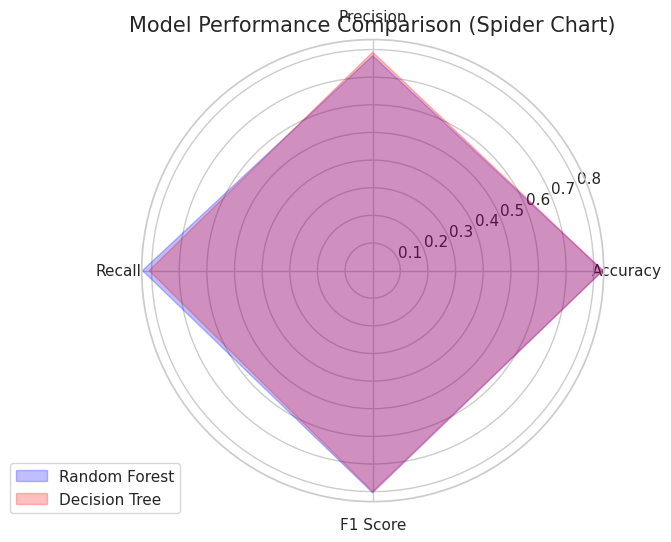

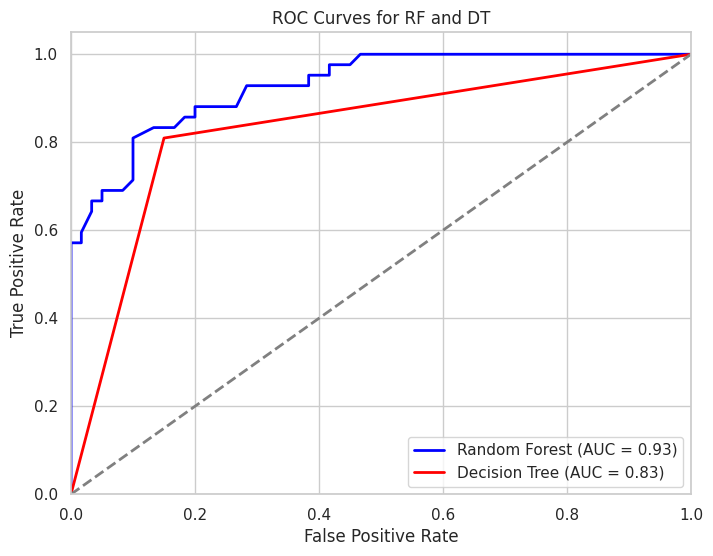

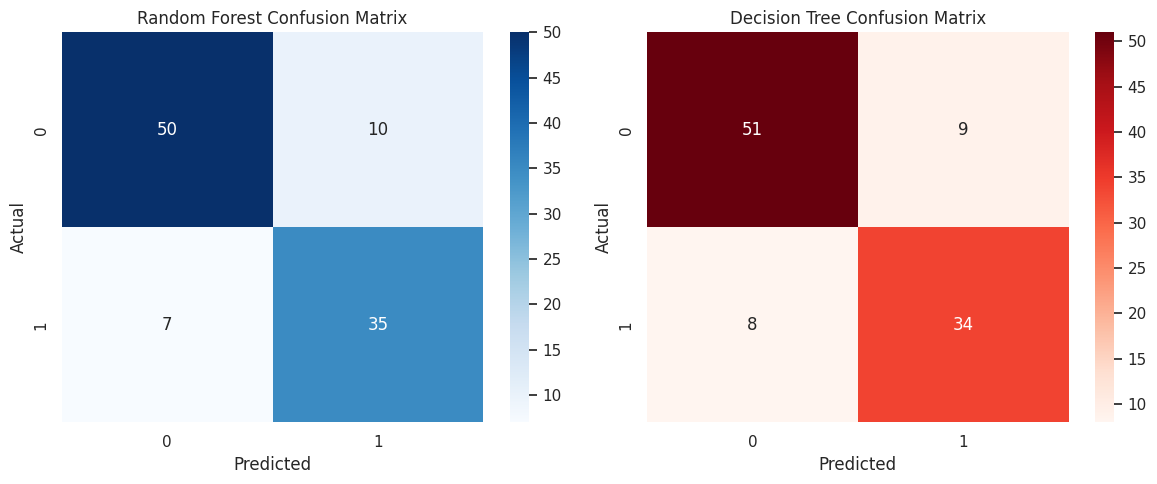

In [16]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Metrics Calculation
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
rf_scores = [accuracy_score(y_test_rf, y_pred_rf), precision_score(y_test_rf, y_pred_rf), recall_score(y_test_rf, y_pred_rf), f1_score(y_test_rf, y_pred_rf)]
dt_scores = [accuracy_score(y_test_dt, y_pred_dt), precision_score(y_test_dt, y_pred_dt), recall_score(y_test_dt, y_pred_dt), f1_score(y_test_dt, y_pred_dt)]

# Spider Chart
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
rf_scores += rf_scores[:1]
dt_scores += dt_scores[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, rf_scores, color='blue', alpha=0.25, label='Random Forest')
ax.fill(angles, dt_scores, color='red', alpha=0.25, label='Decision Tree')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title('Model Performance Comparison (Spider Chart)', size=15)
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

# ROC Curves

# Calculate predicted probabilities for Random Forest
y_pred_rf_proba = rf_classifier.predict_proba(X_test_selected_rf)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_pred_rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculate predicted probabilities for Decision Tree
y_pred_dt_proba = dt_classifier.predict_proba(X_test_selected_dt)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test_dt, y_pred_dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for RF and DT')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test_rf, y_pred_rf), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test_dt, y_pred_dt), annot=True, fmt='d', ax=axes[1], cmap='Reds')
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()